# 📊 Uber Data Analysis Project
## 
 Import Required Libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

##  Load Dataset

In [7]:
df = pd.read_csv("uber_raw_data.csv")
df.head()

,Date/Time,Lat,Lon,Base
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512
3,9/1/2014 0:06:00,40.7450,-73.9889,B02512
4,9/1/2014 0:11:00,40.8145,-73.9444,B02512


##  Data Understanding
- Checking columns
- Checking data types
- Checking dataset structure

In [8]:
df.columns

Index(['Date/Time', 'Lat', 'Lon', 'Base'], dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1028136 entries, 0 to 1028135
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Date/Time  1028136 non-null  str    
 1   Lat        1028136 non-null  float64
 2   Lon        1028136 non-null  float64
 3   Base       1028136 non-null  str    
dtypes: float64(2), str(2)
memory usage: 31.4 MB


## Statistical Summary

In [10]:
df.describe()

,Lat,Lon
count,1.028136e+06,1.028136e+06
mean,4.073922e+01,-7.397182e+01
std,4.082861e-02,5.831413e-02
min,3.998970e+01,-7.477360e+01
25%,4.072040e+01,-7.399620e+01
50%,4.074180e+01,-7.398310e+01
75%,4.076120e+01,-7.396280e+01
max,4.134760e+01,-7.271630e+01


## Missing Values Check

In [11]:
df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

## Data Cleaning
- Convert Date/Time to datetime format
- Remove duplicates

In [12]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

In [13]:
df.duplicated().sum()

np.int64(24037)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

## Feature Engineering
- Extract hour, day, and month from Date/Time

In [16]:
df['hour'] = df['Date/Time'].dt.hour
df['day'] = df['Date/Time'].dt.day_name()
df['month'] = df['Date/Time'].dt.month

## Initial Data Exploration

In [17]:
df['hour'].value_counts()

hour
18    73235
17    71616
19    68033
16    66605
20    62564
15    59768
21    59200
14    51371
22    50649
13    43908
8     43453
7     42272
12    38204
11    37892
9     37696
10    36790
23    35779
6     32484
0     23607
5     19799
1     15737
4     12433
3     10549
2     10455
Name: count, dtype: int64

In [18]:
df['day'].value_counts()

day
Tuesday      159425
Saturday     158081
Friday       156609
Thursday     149614
Monday       134199
Wednesday    132294
Sunday       113877
Name: count, dtype: int64

In [19]:
df['month'].value_counts()

month
9    1004099
Name: count, dtype: int64

## Step 9: Data Visualization
Analyzing ride patterns using graphs

### ⏰ Peak Hours Analysis

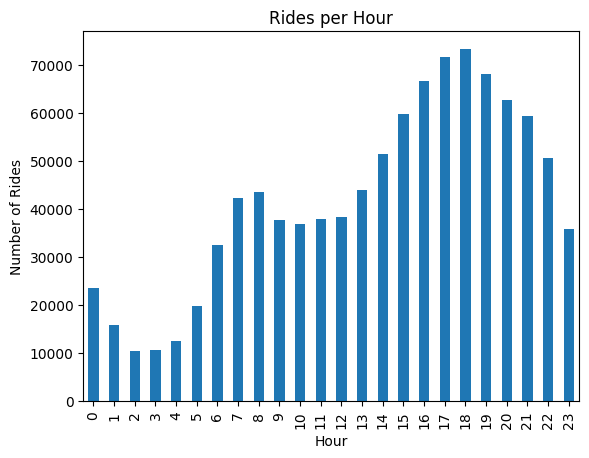

In [20]:
import matplotlib.pyplot as plt

df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Rides per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.show()

### 📅 Day-wise Ride Analysis

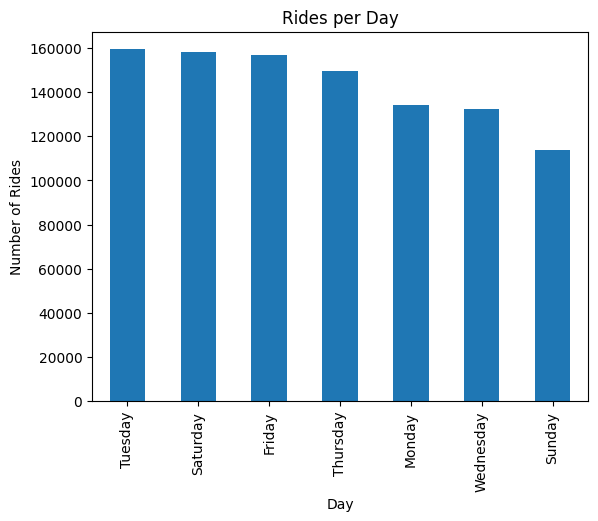

In [21]:
df['day'].value_counts().plot(kind='bar')
plt.title("Rides per Day")
plt.xlabel("Day")
plt.ylabel("Number of Rides")
plt.show()

### 🗓️ Monthly Ride Trend

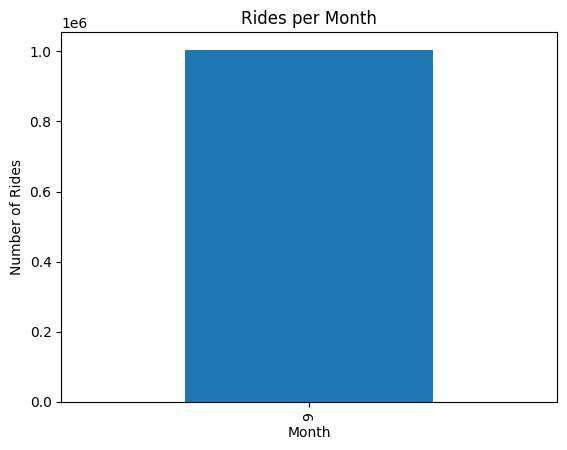

In [22]:
df['month'].value_counts().sort_index().plot(kind='bar')
plt.title("Rides per Month")
plt.xlabel("Month")
plt.ylabel("Number of Rides")
plt.show()

### 🚗 Rides by Base

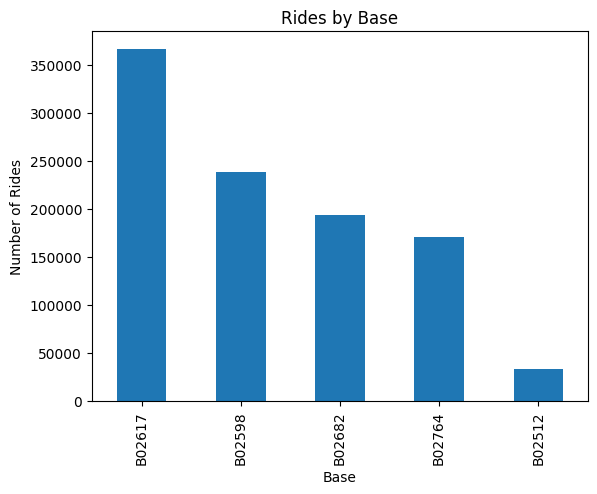

In [23]:
df['Base'].value_counts().plot(kind='bar')
plt.title("Rides by Base")
plt.xlabel("Base")
plt.ylabel("Number of Rides")
plt.show()

###  Hour vs Day Analysis (Ride Density)

In [24]:
pivot = df.pivot_table(index='day', columns='hour', aggfunc='size')

pivot

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day,,,,,,,,,,,,,,,,,,,,,
Friday,2455,1502,981,1317,1779,3029,5045,6535,6543,5485,...,7252,8497,9569,10911,12013,11521,10121,10688,10536,9160
Monday,1842,1179,955,1737,2419,3810,5534,7067,7117,5767,...,6969,8170,9308,9626,9414,8527,8136,6798,5001,2869
Saturday,6747,4599,2893,1985,1434,1516,2047,2738,3592,4259,...,8499,9601,10220,10718,11448,11115,9604,10462,10944,10185
Sunday,7991,5810,3755,2306,1470,1593,1645,2222,3043,3836,...,6529,7006,7471,7211,7015,6274,5795,5047,4033,2293
Thursday,1731,1010,692,1066,1687,2689,5442,7588,7495,6191,...,7234,8664,9924,11025,11437,10699,9852,9585,7705,5051
Tuesday,1378,766,595,1188,2057,4099,7213,9242,9158,6925,...,8170,9697,10880,12069,11891,10840,10139,8827,6398,2890
Wednesday,1463,871,584,950,1587,3063,5558,6880,6505,5233,...,6718,8133,9233,10056,10017,9057,8917,7793,6032,3331


## Key Insights

- Peak ride demand is observed during morning and evening hours
- Weekends show higher ride activity compared to weekdays
- Certain bases have significantly higher ride counts
- Monthly trends indicate variation in demand
- Ride demand fluctuates based on time and day patterns